In [1]:
%run ../../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset import KidneyStoneDataset
from src.pipelines.resnet50_pipeline import resnet50


In [3]:
builder = DatasetBuilder(DATASET_PATH)
task_name= "binario" 
task_config= TASKS[task_name]
df = builder.build(classes=task_config["classes"])
resnet50_model= resnet50(df, Case.IMAGE)



EXPERIMENTO K-FOLD: resnet50_binario
Total images: 397
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 267 images (215 cálculos)
  Val:   39 images (34 cálculos)
  Test:  91 images (63 cálculos)
Device: cuda
Trainable parameters: 525,570
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.5967 acc=0.6705 f1=0.6624 | val: loss=0.5317 acc=0.8718 f1=0.8725 | lr=1.00e-04 | 10.9s
Epoch   2/30 | train: loss=0.5019 acc=0.7689 f1=0.7684 | val: loss=0.4163 acc=0.8974 f1=0.8958 | lr=1.00e-04 | 10.8s
Epoch   3/30 | train: loss=0.4124 acc=0.8068 f1=0.8068 | val: loss=0.4028 acc=0.8718 f1=0.8709 | lr=1.00e-04 | 10.5s
Epoch   4/30 | train: loss=0.3664 acc=0.8447 f1=0.8447 | val: loss=0.3853 acc=0.8974 f1=0.8974 | lr=1.00e-04 | 10.6s
Epoch   5/30 | train: loss=0.4050 acc=0.8106 f1=0.8104 | val: loss=0.4061 acc=0.8462 f1=0.8476 | lr=1.00e-04 | 10.3s
Epoch   6/30 | train: loss=0.3487 acc=0.8674 f1=0.8674 | val: loss=0.4080 acc=0.8205 f1=0.8215 | lr=1.00e

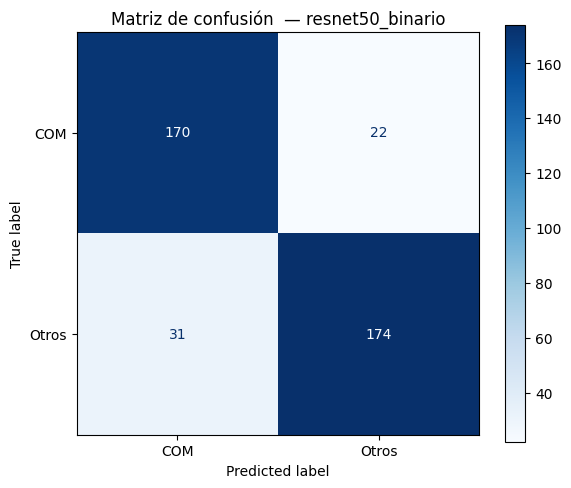


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8647 ± 0.0229
  auc_weighted: 0.9312 ± 0.0161
  f1_weighted: 0.8646 ± 0.0226
  npv_weighted: 0.8632 ± 0.0298
  precision_weighted: 0.8661 ± 0.0228
  recall_weighted: 0.8647 ± 0.0229
  specificity_weighted: 0.8606 ± 0.0213


In [4]:
#con augmentation de datos
config = {
    "name": f"resnet50_{task_name}",
    "output_dir": f"experiments/resnet50/resnet50_images/resnet50_{task_name}",
    "class_names": task_config["class_names"],
    "batch_size": 8

}
resnet50_model.run_model(config, show_fold_metrics= True)
